In [1]:
import pandas as pd

In [6]:
df = pd.read_csv('spam.csv', encoding="latin1")

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [9]:
df = df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)

In [10]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
#renaming data
df.rename({
    'v1':'label',
    'v2':'sms'
},axis=1, inplace=True)
df.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [16]:
df['label'].isnull().sum()
df['sms'].isnull().sum()

np.int64(0)

In [24]:
df.duplicated(keep=False).sum() #this creates a boolean Series where True indicates a duplicate row (including the first occurrence).

np.int64(684)

In [26]:
df[df.duplicated(keep=False)==True] #shows all the duplicate rows

,label,sms
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [27]:
df[df.duplicated()==True] #it shows duplicates of each row excluding the first one

,label,sms
102,ham,As per your request 'Melle Melle (Oru Minnamin...
153,ham,As per your request 'Melle Melle (Oru Minnamin...
206,ham,"As I entered my cabin my PA said, '' Happy B'd..."
222,ham,"Sorry, I'll call later"
325,ham,No calls..messages..missed calls
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [28]:
#dropping the duplicates
df.drop_duplicates(keep='first',inplace=True)

In [29]:
df.shape

(5169, 2)

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


In [32]:
df['label'].value_counts().sum()

np.int64(5169)

In [33]:
(df['label'].value_counts()/df['label'].value_counts().sum())*100

,count
label,
ham,87.366996
spam,12.633004


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5169 non-null   object
 1   sms     5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [42]:
!pip install nltk

In [43]:
from nltk.tokenize import word_tokenize, sent_tokenize

In [44]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
def Count_sentences(sms):
  return len(sent_tokenize(sms))

In [46]:
df.iloc[2,-1]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [47]:
sent_tokenize(df.iloc[2,-1])

['Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005.',
 "Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

In [50]:
def count_words(sms):
  return len(word_tokenize(sms))

In [51]:
df.head(1)

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."


In [52]:
df['Count of sentences'] = df['sms'].apply(Count_sentences)
df['Count of words'] = df['sms'].apply(count_words)

In [53]:
df.head()

,label,sms,Count of sentences,Count of words
0,ham,"Go until jurong point, crazy.. Available only ...",2,24
1,ham,Ok lar... Joking wif u oni...,2,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,2,37
3,ham,U dun say so early hor... U c already then say...,1,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",1,15


In [54]:
import warnings
warnings.filterwarnings('ignore')

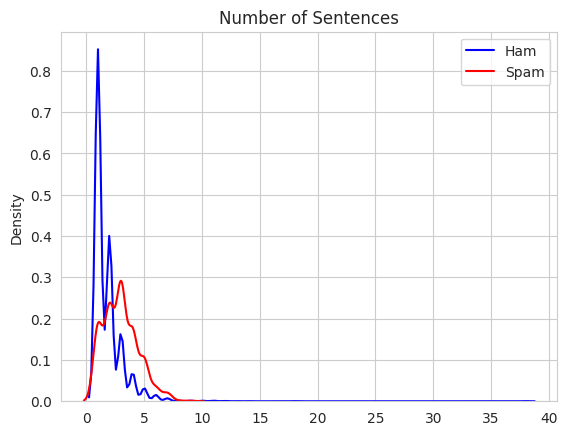

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.distplot(df[df['label']=='ham']['Count of sentences'].values,color='blue', hist=False,label='Ham')
sns.distplot(df[df['label']=='spam']['Count of sentences'].values,color='red', hist=False,label='Spam')
plt.title('Number of Sentences')
sns.set_style(style='whitegrid')
plt.legend()
plt.show()

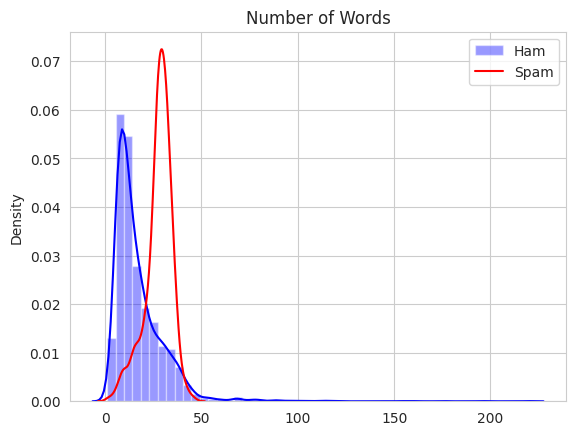

In [60]:
sns.distplot(df[df['label']=='ham']['Count of words'].values,color='blue', hist=True,label='Ham')
sns.distplot(df[df['label']=='spam']['Count of words'].values,color='red', hist=False,label='Spam')
plt.title('Number of Words')
sns.set_style(style='whitegrid')
plt.legend()
plt.show()

In [61]:
df.head(2)

,label,sms,Count of sentences,Count of words
0,ham,"Go until jurong point, crazy.. Available only ...",2,24
1,ham,Ok lar... Joking wif u oni...,2,8


In [62]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [63]:
from nltk.stem import PorterStemmer

In [64]:
object = PorterStemmer()
object.stem('running')

'run'

In [66]:
def Text_preprocessing(text):
  L=[]
  L1=[]
  L2=[]
  #lowercase
  text=text.lower()
  #tokenize
  text=word_tokenize(text)
  # alphabets numbers
  for word in text:
    if word.isalnum():
      L.append(word)
  #remove stopwords
  for word in L:
    if word not in stopwords.words('english'):
      L1.append(word)
  #stem
  for word in L1:
    objec=PorterStemmer()
    L2.append(objec.stem(word))
  #join back


  return ' '.join(L2)

In [67]:
Text_preprocessing('Pakistan has been doing well. They have beaten Afghanistan!')

'pakistan well beaten afghanistan'

In [68]:
df['sms'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [69]:
Text_preprocessing(df['sms'][0])

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [70]:
a= Text_preprocessing(df['sms'][1])

In [71]:
a

'ok lar joke wif u oni'

In [74]:
df['Preprocessed'] = df['sms'].apply(Text_preprocessing)

In [78]:
df.head()

,label,sms,Count of sentences,Count of words,Preprocessed
0,ham,"Go until jurong point, crazy.. Available only ...",2,24,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,2,8,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,2,37,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,1,13,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",1,15,nah think goe usf live around though


In [79]:
df['Preprocessed'][3]

'u dun say earli hor u c alreadi say'

In [80]:
import collections
from collections import Counter

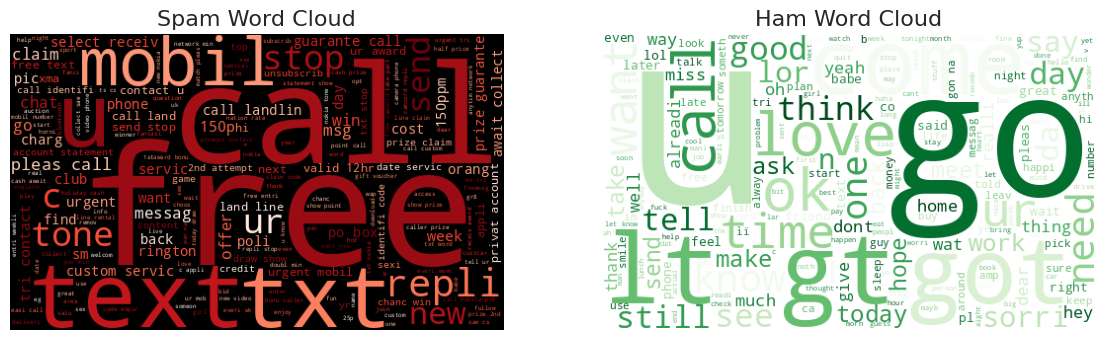

In [88]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_text = " ".join(df[df["label"]=='spam']["Preprocessed"])
ham_text  = " ".join(df[df["label"]=='ham']["Preprocessed"])
# print(spam_text)
fig, ax = plt.subplots(1,2, figsize=(14,6))
ax[0].imshow(WordCloud(width=500, height=300, background_color="black", colormap="Reds").generate(spam_text))
ax[0].set_title("Spam Word Cloud", fontsize=16)
ax[0].axis("off")

ax[1].imshow(WordCloud(width=500, height=300, background_color="white", colormap="Greens").generate(ham_text))
ax[1].set_title("Ham Word Cloud", fontsize=16)
ax[1].axis("off")
plt.show()

In [89]:
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer

# Extract top spam words
spam_text = " ".join(df[df["label"]=='spam']["Preprocessed"])
cv = CountVectorizer(stop_words="english", max_features=30)
X = cv.fit_transform([spam_text])
words = cv.get_feature_names_out()

# Fake hierarchy: root -> word
df_sunburst = pd.DataFrame({
    "category": ["spam"]*len(words),
    "word": words,
    "count": X.toarray()[0]
})

fig = px.sunburst(df_sunburst, path=["category","word"], values="count", color="count",
                  color_continuous_scale="Reds")
fig.update_layout(title="Spam Keyword Sunburst")
fig.show()


In [91]:
# Extract top ham words
ham_text = " ".join(df[df["label"]=='ham']["Preprocessed"])
cv = CountVectorizer(stop_words="english", max_features=30)
X = cv.fit_transform([ham_text])
words = cv.get_feature_names_out()

# Fake hierarchy: root -> word
df_sunburst = pd.DataFrame({
    "category": ["ham"]*len(words),
    "word": words,
    "count": X.toarray()[0]
})

fig = px.sunburst(df_sunburst, path=["category","word"], values="count", color="count",
                  color_continuous_scale="Greens")
fig.update_layout(title="Ham Keyword Sunburst")
fig.show()


In [95]:
X=cv.fit_transform(df['Preprocessed'])
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5425 stored elements and shape (5169, 30)>

In [96]:
X=X.toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [97]:
from sklearn.model_selection import train_test_split
Y=df['label']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [98]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
Y_train=le.fit_transform(Y_train)
Y_test=le.transform(Y_test)

In [99]:
le.classes_

array(['ham', 'spam'], dtype=object)

In [101]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB,ComplementNB
from sklearn.metrics import accuracy_score,precision_score
from sklearn.tree import DecisionTreeClassifier

In [112]:
classifier=DecisionTreeClassifier()
classifier.fit(X_train,Y_train)
YP=classifier.predict(X_test)
precision_score(Y_test,YP)

0.8695652173913043

In [111]:
classifier=GaussianNB()
classifier.fit(X_train,Y_train)
YP=classifier.predict(X_test)
precision_score(Y_test,YP)

0.1775

In [110]:
classifier=MultinomialNB()
classifier.fit(X_train,Y_train)
YP=classifier.predict(X_test)
precision_score(Y_test,YP)

0.7941176470588235

In [113]:
classifier=BernoulliNB()
classifier.fit(X_train,Y_train)
YP=classifier.predict(X_test)
precision_score(Y_test,YP)

0.7980769230769231

In [114]:
X_test[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [115]:
classifier=ComplementNB()
classifier.fit(X_train,Y_train)
YP=classifier.predict(X_test)
precision_score(Y_test,YP)

classifier.predict([X_test[0]])

array([0])

In [116]:
import plotly.graph_objects as go

test_email = "Congratulations! You have won a free vacation."

t=Text_preprocessing(test_email)

test=cv.transform([t]).toarray()
# print(test)
prob = classifier.predict_proba(test)[0][1]  # Spam probability

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=prob*100,
    title={'text': "Spam Probability (%)"},
    gauge={'axis': {'range': [0,100]}, 'bar': {'color': "red"}}
))
fig.show()


In [117]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
print(sia.polarity_scores("Congratulations! You have won a free vacation."))

{'neg': 0.0, 'neu': 0.211, 'pos': 0.789, 'compound': 0.9041}


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
